# Gráficas
## `plot()`

Cada llamada a `plot()` genera una salida gráfica automática. 
En el siguiente ejemplo sencillo, se define x como una secuencia de números desde el -50 al 50. Es decir $x=(-50, -49,...,49, 50) = (x_{1},...,x_{n})$. Por otro lado si queremos dibujar la función: $$f(x) = x^2$$
Podemos decir que si tomamos a la sucesión $y = (x_{1}^2,...,x_{n}^2)$. 

El hacer `plot(x,y)` nos dará como resutado la gráfica de la parábola descrita por los puntos $ ((x_{1},y_{1}),...,(x_{n},y_{n})) $. Es decir...$ f(x)=x^2 $.




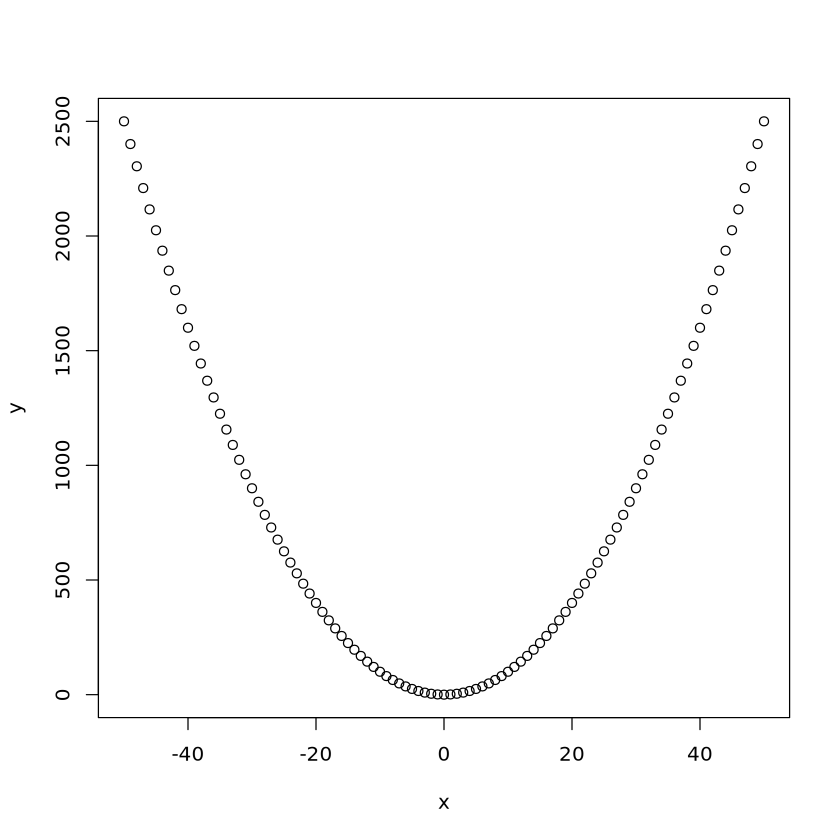

In [1]:
x <- -50:50
y <- x^2
plot(x, y)

En este segundo ejemplo x es una secuencia de 100 números desde el 0 al 2pi y dibujamos la funcion:
$$ f(x)=sen(x) $$


In [ ]:
x <- seq(0, 2*pi, length.out = 100)
plot(x, sin(x), main="Gráfica de la función seno de x")

In [ ]:
?plot

### Parámetros de `plot()`

#### Datos
- **x, y**: vectores numéricos del mismo largo. `x` en el eje horizontal y `y` en el vertical.

#### Apariencia básica
- **type**: qué dibujar.
  - `"p"` puntos, `"l"` líneas, `"b"` puntos+líneas, `"o"` superpuestos,
    `"h"` barras verticales, `"s"` y `"S"` escalones, `"n"` no dibuja.
- **pch**: símbolo del punto. 0–25 formas básicas; 16 círculo sólido; también puede ser un carácter `"+"`, `"*"`, etc.
- **col**: color de puntos y líneas. Nombre `"steelblue"`, código `"#RRGGBB"`, o vector por grupo.
- **lwd**: grosor de línea en múltiplos del ancho base. Ej.: `2` más gruesa.
- **lty**: tipo de línea. `1` sólida, `2` discontinua, `3` punteada, `4` punteado–discontinua, `5` larga discontinua, `6` dos puntos.

#### Etiquetas y título
- **xlab**, **ylab**: etiquetas de ejes.
- **main**: título del gráfico. `sub` agrega subtítulo.

#### Rango de ejes
- **xlim = c(xmin, xmax)**: límites del eje x.
- **ylim = c(ymin, ymax)**: límites del eje y.
  - Útiles para fijar escalas, comparar paneles, o evitar auto-recorte.

#### Ejes y anotaciones
- **axes**: `TRUE` dibuja ejes y caja automáticamente. `FALSE` para personalizarlos con `axis()` y `box()`.
- **ann**: `TRUE` dibuja anotaciones automáticas (`main`, `xlab`, `ylab`). `FALSE` las omite.

---

#### Notas prácticas
- Muchos argumentos aceptan **vectores** para estilizar por punto/serie: `col = grupo`, `pch = c(16,1)[grupo]


In [ ]:
x <- seq(0, 2*pi, length.out = 100)
y<- sin(x)
plot(
  x, y,
  type = "p",
  pch  = (1:100)%%26,   #aqui una serie para que muestre los distintos tipos de punto
  col  = "steelblue",
  lwd  = 2,
  lty  = 1,
  xlab = "x", ylab = "y",
  main = "Título",
  xlim = c(0, 2*pi), ylim = c(-1, 1),
  axes = TRUE,
  ann  = TRUE
)


## Guardar Gráfico en un Archivo
El concepto de “guardar”  en R implica los siguientes pasos

* Abrir un “dispositivo” (= tipo de archivo) para graficar (El ejemplo muestra un "dispositivo" que será un archivo pdf). Esto incluye el nombre del archivo y otros parámetros de configuración como el ancho y la altura.
  * Los atrbutos `width` y `height`,  se miden en pulgadas del lienzo PDF. Por defecto son 7×7 pulgadas. (1 pulgada = 72 puntos en PDF).
  *  `pointsize` controla el tamaño base del texto en puntos.
* Escribir todos los comandos de trazado y personalización como de costumbre en `plot`
  * Datos
  * Apariencia básica: `type`, `pch`, `col`, etc...
  * Etiquetas y Título
  * Rango de ejes
  * Ejes y Anotaciones
* Cerrar el "dispositivo" (archivo) con `dev.close()`

Esto escribe el gráfico en el archivo PDF que hemos llamado trigonometria.pdf.

Los siguientes dispositivos gráficos están actualmente disponibles en R:

* `pdf` Escribe los gráficos a un archivo PDF
* `postscript` Escribe los gráficos a un fichero PostScript (.ps)
* `xfig` Sería el dispositivo para un archivo con formato XFIG
* `bitmap` Utilizario un bitmap creado a partir de Ghostscript (si está disponible Ghostscript)
* `pictex` Escribe a un archivo TeX/PicTeX los gráficos (Se mantien por interés histórico, no se usa actualmente)

Además de los anteriores en algunas distribuciones de R tenemos también tendremos estos otros dispositivos: (si no están permitidos para nuestra compilación de R devolverán un WARNING)
* `X11` Es un gráfico para el sistemas operativo  de ventana X11. Como en nuestro caso no tenemos cargado un gestor de ventanas en la máquina WSL on Ubuntu, pues no puee funcionar.
* `cairo_pdf`,  based on cairo graphics.
* `svg` devolverá un archivo SVG.
* `png` un bitmap de tipo PNG
* `jpeg` un bitmap de tipo JPEG
* `bmp` un bitmap de tipo BMP
* `tiff`un bitmap de tipo TIFF
* `quartz` para los Mac puede usarse este formato de imagen nativo en OS X


En el Ejemplo: 

* `pdf()` Define el "dispositivo" la salida ahora será hacia este archivo.
* `par()` sirve para consultar y/o fijar _parámetros gráficos globales_ en R.
  * `mfrow = c(1, 3)`: divide la ventana gráfica en 1 fila y 3 columnas → podrás hacer 3 gráficos uno al lado del otro. (_multiple figures, filled by row_ , y por supuesto también hay un mfcol)
  * `oma = c(0, 0, 3, 0)`: define el tamaño de los márgenes externos (_outer margins_) en líneas de texto: `c(inferior, izquierda, superior, derecha)`
* `plot()` es la gráfica en sí y la salida será el PDF ( dispositivo) hasta que se cierre
* `mtext()`: Sirve para escribir texto en los márgenes de la figura (_margin text_). No dentro del área del gráfico, sino alrededor.
  * `outer = TRUE`: coloca el texto en el margen externo (definido por oma), no en el margen interno de cada subgráfico.
  * `side = 3`: lado donde va el texto 1 = abajo, 2 = izquierda, 3 = arriba, 4 = derecha.
  * `line = 1`: en qué línea del margen se coloca, contando desde el borde del área de dibujo hacia afuera.
  * `cex`, `font`: tamaño relativo y tipo de letra.
* `dev.close()`: Cierra el dispositivo. A partir de esta línea la salida se hará nuevamente a pantalla. `pdf` y `dev` están relacionados.  

In [ ]:
x <- seq(0, 2*pi, length.out = 100)
pdf("trigonometría.pdf", width=12, height=4, pointsize=12)  # 12 y 4 está en pulgadas.= A4
par(mfrow = c(1, 3),      # 1 fila con 3 columnas para 3 gráficas
    oma = c(0, 0, 3, 0))  # margen externo arriba para el título
plot(x, sin(x), main="Gráfica de sin(x)")
plot(x, cos(x), main="Gráfica de cos(x)", type="o", col="blue", lty=2)
plot(x, tan(x), main="Gráfica de tan(x)", type="l", col="red")

mtext("Ejemplo Plot a PDF", outer = TRUE, side = 3, line = 1, cex = 1.3, font = 2)  # título centrado

dev.off()

In [ ]:
# Secuencia de valores
x <- seq(-10, 10, length.out = 400)

# Densidad
y <- dnorm(x, mean = 0, sd =2)

# Gráfico
plot(x, y, type = "l", lwd = 2, col = "steelblue",
     main = "Distribución normal N(0, 2²)",
     xlab = "x", ylab = "densidad")

# Línea vertical en la media
abline(v = 0, col = "red", lty = 2)
abline(v = 10, col = "red", lty = 2)


In [ ]:
#set.seed(1)
x <- 1:20
y1 <- x  #+ rnorm(20, 0, 2) # genera 20 números aleatorios según la normal de media=0 y desviación típica=2
y2 <- x*1.2  #+ rnorm(20, mean=0, sd=2)

plot(x, y1, pch = 16, col = "black", main = "Capas")
lines(x, y1, lwd = 2)
points(x, y2, pch = 1, col = "firebrick")
lines(x, y2, lty = 2, lwd = 2, col = "firebrick")
abline(h = mean(y1), lty = 3)
abline(v = 10, lty = 3)
legend("topleft",
       legend = c("Serie 1", "Serie 2"),
       pch = c(16, 1), lty = c(1, 2),
       col = c("black", "firebrick"), bty = "n")


In [ ]:
t <- seq(0, 2*pi, length.out = 200)
M <- cbind(sin(t), cos(t), sin(t)^2)
matplot(t, M, type = "l", lty = 1, lwd = 2,
        col = c("black", "blue", "red"),
        xlab = "t", ylab = "valor", main = "Varias Series")
legend("bottomleft", legend = c("sin", "cos", "sin^2"),
       lty = 1, lwd = 2, col = c("black", "steelblue", "firebrick"), bty = "n")


In [ ]:
op <- par(mfrow = c(1, 2))
plot(rnorm(200), main = "N(0,1)", pch = 16) # 200 puntos siguiendo una distribución Normal=Gaussiana
hist(rchisq(500, df = 3), main = "Chi-cuadrado df=3")
par(op)

In [ ]:
?rchisq

In [ ]:
print("https://people.duke.edu/~ccc14/ngs-2015/IntroductionToR.html")